<a href="https://colab.research.google.com/github/manoj791/predictive/blob/house_price_prediction/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Error: 'your_house_data.csv' not found. Please upload or provide the correct path to your dataset.
Using a dummy dataset for demonstration.
Mean Squared Error: 147858310.85815048
R-squared: 0.9934285195174155


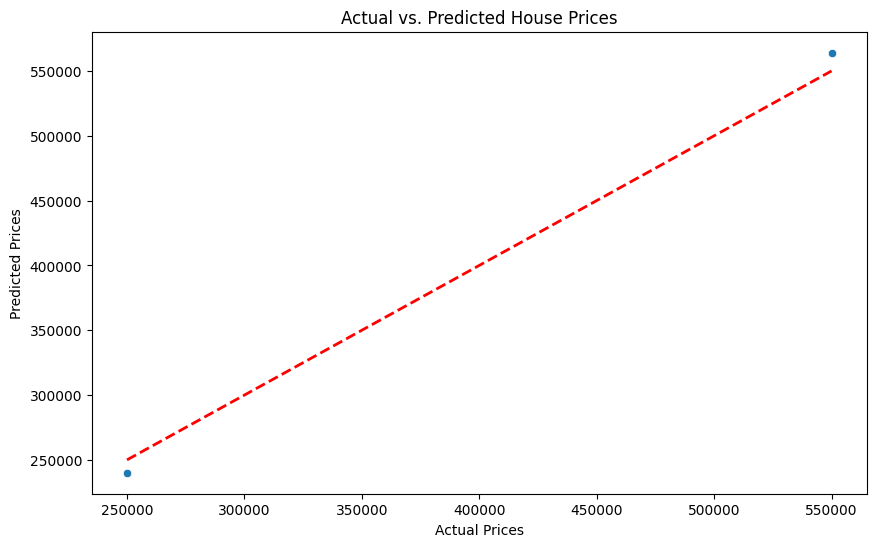


Predicted price for a new house with features {'size_sqft': 1600, 'bedrooms': 3, 'bathrooms': 2}: $321,198.16


In [14]:
!pip install scikit-learn pandas matplotlib seaborn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
try:
    df = pd.read_csv('your_house_data.csv')
except FileNotFoundError:
    print("Error: 'your_house_data.csv' not found. Please upload or provide the correct path to your dataset.")
    # Create a dummy dataset for demonstration if file is not found
    data = {'size_sqft': [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000],
            'bedrooms': [2, 3, 3, 4, 4, 4, 5, 5, 5],
            'bathrooms': [1, 2, 2, 2, 3, 3, 3, 4, 4],
            'price': [200000, 250000, 300000, 350000, 400000, 450000, 500000, 550000, 600000]}
    df = pd.DataFrame(data)
    print("Using a dummy dataset for demonstration.")


# Define features (X) and target (y)
# Replace 'price' with the name of your target variable column
# Replace the list with the names of your feature columns
X = df[['size_sqft', 'bedrooms', 'bathrooms']]
y = df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Optional: Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.show()
# Example prediction for a new house (replace values)
new_house_features = pd.DataFrame({'size_sqft': [1600], 'bedrooms': [3], 'bathrooms': [2]})
predicted_price = model.predict(new_house_features)
print(f"\nPredicted price for a new house with features {new_house_features.iloc[0].to_dict()}: ${predicted_price[0]:,.2f}")

In [ ]:
# prompt: accuracy for the abovecode

print(f'R-squared: {r2}')

Error: 'creditcard.csv' not found. Please upload or provide the correct path to your dataset.
Using a dummy dataset for demonstration.
Isolation Forest Evaluation:
Confusion Matrix:
[[ 51 147]
 [  0   2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.26      0.41       198
           1       0.01      1.00      0.03         2

    accuracy                           0.27       200
   macro avg       0.51      0.63      0.22       200
weighted avg       0.99      0.27      0.41       200


Accuracy Score:
0.265


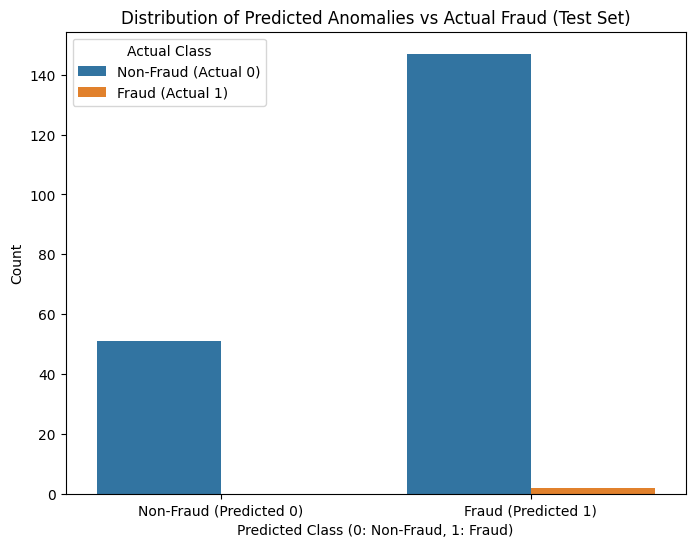

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Install libraries (already done in the first cell, but kept here for completeness)
!pip install scikit-learn pandas matplotlib seaborn

# Load the dataset (replace 'creditcard.csv' with your file path)
try:
    df = pd.read_csv('creditcard.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please upload or provide the correct path to your dataset.")
    # Create a dummy dataset for demonstration if file is not found
    data = {f'V{i}': [np.random.rand() * 1000 for _ in range(1000)] for i in range(1, 29)}
    data['Amount'] = [np.random.rand() * 1000 for _ in range(1000)]
    data['Time'] = [i for i in range(1000)]
    data['Class'] = [0] * 990 + [1] * 10  # Create an imbalanced dataset
    df = pd.DataFrame(data)
    print("Using a dummy dataset for demonstration.")

# Drop the 'Time' column as it's not typically used in this type of model
df = df.drop(['Time'], axis=1)

# Define features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create an Isolation Forest model
# Isolation Forest is suitable for anomaly detection (fraud is an anomaly)
model = IsolationForest(n_estimators=100, contamination='auto', random_state=42)

# Train the model
model.fit(X_train)

# Make predictions on the test set
# Isolation Forest predicts -1 for anomalies (fraud) and 1 for inliers (non-fraud)
y_pred_test_iso = model.predict(X_test)

# Convert predictions to 0 (non-fraud) and 1 (fraud) to match the original 'Class' column
y_pred_test_iso = [1 if i == -1 else 0 for i in y_pred_test_iso]

# Evaluate the model
print("Isolation Forest Evaluation:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_iso))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_iso))
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred_test_iso))

# Visualize the results
plt.figure(figsize=(8, 6))
sns.countplot(x=y_pred_test_iso, hue=y_test)
plt.title('Distribution of Predicted Anomalies vs Actual Fraud (Test Set)')
plt.xlabel('Predicted Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Fraud (Predicted 0)', 'Fraud (Predicted 1)'])
plt.legend(title='Actual Class', labels=['Non-Fraud (Actual 0)', 'Fraud (Actual 1)'])
plt.show()

Dataset loaded successfully.


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Evaluation:
Confusion Matrix:
[[66 11]
 [11 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.82      0.82      0.82        61

    accuracy                           0.84       138
   macro avg       0.84      0.84      0.84       138
weighted avg       0.84      0.84      0.84       138

Accuracy Score: 0.8405797101449275


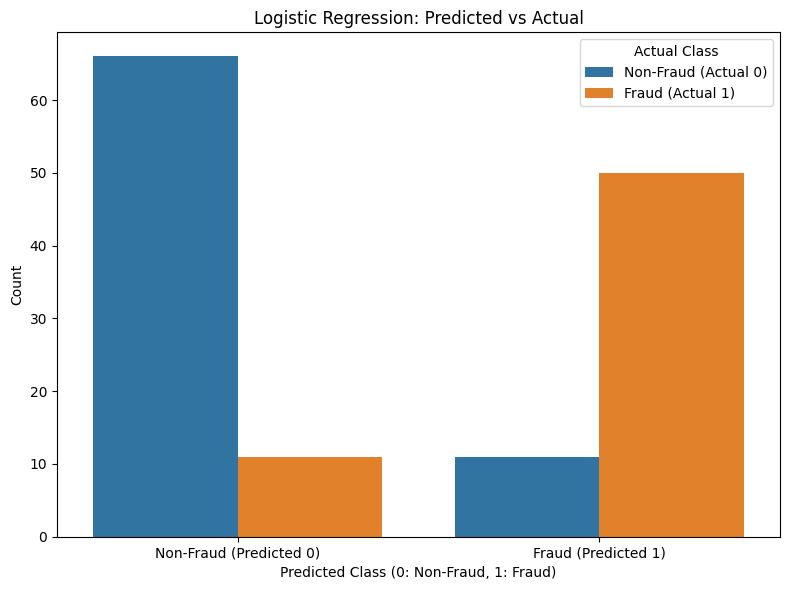

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (ensure creditcard.csv is present in the same directory)
df = pd.read_csv('/content/Credit_Card_Applications.csv')
print("Dataset loaded successfully.")

# Define features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Logistic Regression model with class weight
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Logistic Regression Evaluation:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Visualization
plt.figure(figsize=(8, 6))
sns.countplot(x=y_pred, hue=y_test)
plt.title('Logistic Regression: Predicted vs Actual')
plt.xlabel('Predicted Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Fraud (Predicted 0)', 'Fraud (Predicted 1)'])
plt.legend(title='Actual Class', labels=['Non-Fraud (Actual 0)', 'Fraud (Actual 1)'])
plt.tight_layout()
plt.show()